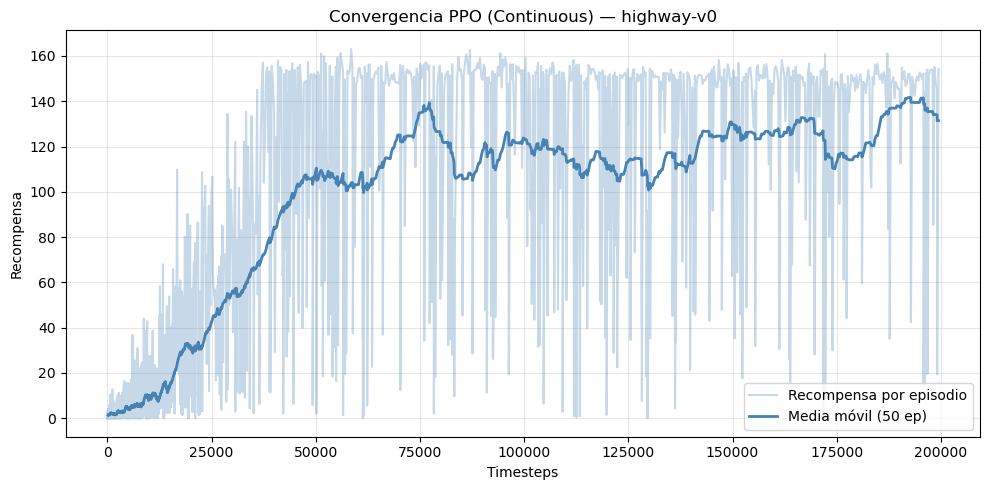

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3.common.results_plotter import load_results, ts2xy

window = 50
env_name = 'highway-v0'
root = f'{env_name}-PPO-C'
log_folder= f'{root}/logs/'
x, y = ts2xy(load_results(log_folder), "timesteps")

# Media móvil
if len(y) >= window:
    moving_avg = np.convolve(y, np.ones(window) / window, mode="valid")
    x_avg = x[window - 1:]
else:
    moving_avg, x_avg = y, x

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, y, alpha=0.3, color="steelblue", label="Recompensa por episodio")
ax.plot(x_avg, moving_avg, color="steelblue", linewidth=2, label=f"Media móvil ({window} ep)")
ax.set_xlabel("Timesteps")
ax.set_ylabel("Recompensa")
ax.set_title(f"Convergencia PPO (Continuous) — {env_name}")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{root}/convergencia_ppo_continuous.png", dpi=150)
plt.show()